In [4]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface
import spikeinterface.exporters as sexp
from spikeinterface.core import write_binary_recording
from pathlib import Path
import pickle

In [6]:
# 1. 绘制waveform PDF（所有clique合并到一个PDF，每页多个子图）
base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')
sampling_frequency = 20000  # Hz

# 收集所有clique的neuron信息
all_neuron_data = []  # [(clique_id, neuron_name, position_waveform), ...]

# 遍历所有clique
for clique_id in range(4):
    clique_dir = base_dir / f'clique_{clique_id}'
    date_dir = clique_dir / 'date_1214'
    neuron_inf_path = date_dir / 'neuron_inf.pickle'
    
    if not neuron_inf_path.exists():
        print(f"跳过clique_{clique_id}: neuron_inf.pickle不存在")
        continue
    
    # 读取neuron_inf
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf = pickle.load(f)
    
    # 如果是dict，转换为DataFrame
    if isinstance(neuron_inf, dict):
        neuron_inf = pd.DataFrame.from_dict(neuron_inf, orient='index')
        if 'Neuron' not in neuron_inf.columns:
            neuron_inf['Neuron'] = neuron_inf.index
    
    print(f"处理clique_{clique_id}: {len(neuron_inf)} 个neuron")
    
    # 收集neuron数据
    for idx, row in neuron_inf.iterrows():
        neuron_name = row['Neuron']
        position_waveform = row.get('position_waveform', None)
        
        if position_waveform is None:
            print(f"  警告: {neuron_name} 没有position_waveform，跳过")
            continue
        
        # 转换为numpy数组
        waveform = np.asarray(position_waveform, dtype=np.float32)
        if len(waveform) == 0:
            print(f"  警告: {neuron_name} 的waveform为空，跳过")
            continue
        
        all_neuron_data.append((clique_id, neuron_name, waveform))

print(f"\n总共收集到 {len(all_neuron_data)} 个neuron的waveform数据")

# 生成单个PDF，每页显示多个子图
output_pdf_path = base_dir / 'waveforms.pdf'
rows_per_page = 4  # 每页行数
cols_per_page = 4  # 每页列数
neurons_per_page = rows_per_page * cols_per_page  # 每页显示的neuron数量

with PdfPages(output_pdf_path) as pdf:
    total_neurons = len(all_neuron_data)
    num_pages = (total_neurons + neurons_per_page - 1) // neurons_per_page  # 向上取整
    
    for page_idx in range(num_pages):
        start_idx = page_idx * neurons_per_page
        end_idx = min(start_idx + neurons_per_page, total_neurons)
        page_data = all_neuron_data[start_idx:end_idx]
        
        # 创建子图
        fig, axes = plt.subplots(rows_per_page, cols_per_page, figsize=(16, 12))
        axes = axes.flatten() if rows_per_page > 1 or cols_per_page > 1 else [axes]
        
        for subplot_idx, (clique_id, neuron_name, waveform) in enumerate(page_data):
            if subplot_idx >= len(axes):
                break
            
            ax = axes[subplot_idx]
            
            # 创建时间轴（毫秒）
            time_points = np.arange(len(waveform)) / sampling_frequency * 1000  # 转换为毫秒
            
            # 绘制waveform
            ax.plot(time_points, waveform, 'b-', linewidth=1.5)
            ax.set_xlabel('Time (ms)', fontsize=10)
            ax.set_ylabel('Amplitude', fontsize=10)
            ax.set_title(f'Clique_{clique_id} - {neuron_name}', fontsize=10, fontweight='bold')
            # 删除grid
            ax.grid(False)
        
        # 隐藏多余的子图
        for subplot_idx in range(len(page_data), len(axes)):
            axes[subplot_idx].axis('off')
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()

print(f"✓ 已保存waveform PDF: {output_pdf_path} (共 {num_pages} 页)")


处理clique_0: 17 个neuron
处理clique_1: 12 个neuron
处理clique_2: 13 个neuron
处理clique_3: 31 个neuron

总共收集到 73 个neuron的waveform数据
✓ 已保存waveform PDF: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/waveforms.pdf (共 5 页)


In [9]:
# 2. 绘制raster plot（所有clique合并，一页PDF）
base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')
dates = [1214, 1215, 1216, 1217, 1218, 1219]
sampling_frequency = 20000  # Hz

# 直接从所有gt_detect_array.csv中收集所有唯一的(clique_id, unit_id)组合
all_unit_keys = set()  # {(clique_id, unit_id), ...}

# 遍历所有clique和日期，收集所有(clique_id, unit_id)组合
for clique_id in range(4):
    clique_dir = base_dir / f'clique_{clique_id}'
    
    for date in dates:
        date_dir = clique_dir / f'date_{date}'
        gt_detect_array_path = date_dir / 'gt_detect_array.csv'
        
        if not gt_detect_array_path.exists():
            continue
        
        # 读取gt_detect_array
        try:
            gt_detect_array = pd.read_csv(gt_detect_array_path)
            
            # 收集所有unit_id（与clique_id组合）
            if 'unit_id' in gt_detect_array.columns:
                for unit_id in gt_detect_array['unit_id'].unique():
                    all_unit_keys.add((clique_id, unit_id))
            elif 'cluster' in gt_detect_array.columns:
                for unit_id in gt_detect_array['cluster'].unique():
                    all_unit_keys.add((clique_id, unit_id))
        except Exception as e:
            print(f"  警告: 无法读取 {gt_detect_array_path}: {e}")
            continue

# 排序所有(clique_id, unit_id)组合（先按clique_id，再按unit_id）
all_unit_keys_sorted = sorted(all_unit_keys, key=lambda x: (x[0], str(x[1])))
print(f"总共找到 {len(all_unit_keys_sorted)} 个唯一的(clique_id, unit_id)组合")

# 收集每个日期每个(clique_id, unit_id)的spike times
unit_spike_times = {}  # {(clique_id, unit_id): {date: [spike_times_in_seconds]}}

for clique_id, unit_id in all_unit_keys_sorted:
    unit_key = (clique_id, unit_id)
    unit_spike_times[unit_key] = {}
    
    for date in dates:
        unit_spike_times[unit_key][date] = []
        
        # 只从对应的clique查找该unit_id的spike
        clique_dir = base_dir / f'clique_{clique_id}'
        date_dir = clique_dir / f'date_{date}'
        gt_detect_array_path = date_dir / 'gt_detect_array.csv'
        
        if not gt_detect_array_path.exists():
            continue
        
        # 读取gt_detect_array
        try:
            gt_detect_array = pd.read_csv(gt_detect_array_path)
        except Exception as e:
            continue
        
        # 直接匹配unit_id（只在该clique中）
        if 'unit_id' in gt_detect_array.columns:
            # 尝试直接匹配（可能是字符串或数字）
            unit_spikes = gt_detect_array[gt_detect_array['unit_id'] == unit_id]
            if len(unit_spikes) == 0:
                # 尝试转换为字符串匹配
                unit_spikes = gt_detect_array[gt_detect_array['unit_id'].astype(str) == str(unit_id)]
            
            if len(unit_spikes) > 0:
                time_values = unit_spikes['time'].values
                # 判断time单位：如果最大值>100000，可能是sample indices
                if time_values.max() > 100000:
                    spike_times_seconds = time_values / sampling_frequency
                else:
                    spike_times_seconds = time_values
                # 只保留前300秒的数据
                spike_times_seconds = spike_times_seconds[spike_times_seconds <= 50]
                unit_spike_times[unit_key][date].extend(spike_times_seconds.tolist())
        
        # 如果unit_id列不存在，尝试cluster列
        elif 'cluster' in gt_detect_array.columns:
            cluster_spikes = gt_detect_array[gt_detect_array['cluster'] == unit_id]
            if len(cluster_spikes) == 0:
                cluster_spikes = gt_detect_array[gt_detect_array['cluster'].astype(str) == str(unit_id)]
            
            if len(cluster_spikes) > 0:
                time_values = cluster_spikes['time'].values
                if time_values.max() > 100000:
                    spike_times_seconds = time_values / sampling_frequency
                else:
                    spike_times_seconds = time_values
                # 只保留前300秒的数据
                spike_times_seconds = spike_times_seconds[spike_times_seconds <= 50]
                unit_spike_times[unit_key][date].extend(spike_times_seconds.tolist())

# 计算每个日期的记录时长（用于x轴比例）
# 由于只取前300秒，所有日期统一使用300秒
max_duration_per_date = 50  # 每个日期最多300秒
date_durations = {date: max_duration_per_date for date in dates}

print(f"各日期记录时长（限制为前300秒）: {date_durations}")

# 绘制raster plot（分成两页，每页使用tab20颜色）
output_pdf_path = base_dir / 'raster_plot.pdf'

# 获取tab20 colormap
tab20_cmap = plt.cm.get_cmap('tab20')
n_colors = 20  # tab20有20种颜色

# 将units分成两页
units_per_page = (len(all_unit_keys_sorted) + 1) // 2  # 向上取整
num_pages = 2

# 计算x轴的总范围和每个日期的起始位置
total_duration = sum(date_durations.values())
date_starts = {}  # {date: start_x_position}
current_x = 0
for date in dates:
    date_starts[date] = current_x
    current_x += date_durations[date]

with PdfPages(output_pdf_path) as pdf:
    for page_idx in range(num_pages):
        start_idx = page_idx * units_per_page
        end_idx = min(start_idx + units_per_page, len(all_unit_keys_sorted))
        page_units = all_unit_keys_sorted[start_idx:end_idx]
        
        fig, ax = plt.subplots(figsize=(32, max(8, len(page_units) * 0.3)))
        
        # 绘制每个(clique_id, unit_id)的spike
        for y_idx, unit_key in enumerate(page_units):
            y_pos = len(page_units) - y_idx - 1  # 从顶部开始
            
            color = tab20_cmap(y_idx % n_colors)
            
            for date in dates:
                spike_times = unit_spike_times[unit_key].get(date, [])
                if len(spike_times) > 0:
                    # 将spike times映射到x轴位置
                    x_positions = [date_starts[date] + t for t in spike_times]
                    # 绘制spike（使用vlines，使用tab20颜色）
                    ax.vlines(x_positions, y_pos - 0.4, y_pos + 0.4, 
                             colors=color, linewidths=0.5, alpha=0.7)
        
        for i, date in enumerate(dates[:-1]):
            x_boundary = date_starts[dates[i+1]]
            ax.axvline(x=x_boundary, color='black', linestyle='--', linewidth=3, alpha=1)
        
        ax.set_xlim(0, total_duration)
        ax.set_ylim(-0.5, len(page_units) - 0.5)
        
        ax.axis('off')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()

print(f"✓ 已保存raster plot PDF: {output_pdf_path} (共 {num_pages} 页)")


总共找到 124 个唯一的(clique_id, unit_id)组合
各日期记录时长（限制为前300秒）: {1214: 50, 1215: 50, 1216: 50, 1217: 50, 1218: 50, 1219: 50}
✓ 已保存raster plot PDF: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/raster_plot.pdf (共 2 页)


成功读取数据，矩阵形状: (4, 5, 2)
有效数据点数量: 40 / 40

各clique的均值 (noise, label):
  Clique 0: 0.9653, 0.9965
  Clique 1: 0.9651, 0.9986
  Clique 2: 0.9717, 0.9943
  Clique 3: 0.9700, 0.9812


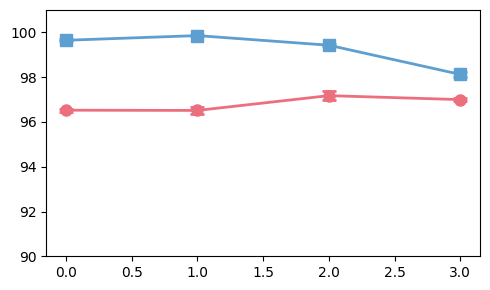

In [19]:
# 3. 读取所有clique所有重复的training_log.csv，提取best accuracy并绘制图表
base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')
n_clique = 4
n_rep = 5  # model_1 到 model_5
date = 1214

# 初始化矩阵 (n_clique, n_rep, 2)
# 维度0: clique_id (0-3)
# 维度1: repetition (0-4, 对应model_1到model_5)
# 维度2: [noise_acc, label_acc]
accuracy_matrix = np.full((n_clique, n_rep, 2), np.nan)

# 遍历所有clique和重复
for clique_id in range(n_clique):
    clique_dir = base_dir / f'clique_{clique_id}'
    date_dir = clique_dir / f'date_{date}'
    
    for rep_idx in range(n_rep):
        model_dir = date_dir / f'model_{rep_idx + 1}'
        training_log_path = model_dir / 'training_log.csv'
        
        if not training_log_path.exists():
            print(f"警告: {training_log_path} 不存在，跳过")
            continue
        
        try:
            # 读取training_log.csv
            df = pd.read_csv(training_log_path)
            
            # 提取best accuracy（每列的最大值）
            if 'validation_acc_noise' in df.columns:
                best_noise_acc = df['validation_acc_noise'].max()
            else:
                print(f"警告: {training_log_path} 中没有validation_acc_noise列")
                best_noise_acc = np.nan
            
            if 'validation_acc_label' in df.columns:
                best_label_acc = df['validation_acc_label'].max()
            else:
                print(f"警告: {training_log_path} 中没有validation_acc_label列")
                best_label_acc = np.nan
            
            # 存储到矩阵中
            accuracy_matrix[clique_id, rep_idx, 0] = best_noise_acc
            accuracy_matrix[clique_id, rep_idx, 1] = best_label_acc
            
        except Exception as e:
            print(f"错误: 无法读取 {training_log_path}: {e}")
            continue

print(f"成功读取数据，矩阵形状: {accuracy_matrix.shape}")
print(f"有效数据点数量: {np.sum(~np.isnan(accuracy_matrix))} / {accuracy_matrix.size}")

# 计算每个clique的均值和标准差
clique_means = np.nanmean(accuracy_matrix, axis=1)  # (n_clique, 2)
clique_stds = np.nanstd(accuracy_matrix, axis=1)   # (n_clique, 2)

print(f"\n各clique的均值 (noise, label):")
for clique_id in range(n_clique):
    print(f"  Clique {clique_id}: {clique_means[clique_id, 0]:.4f}, {clique_means[clique_id, 1]:.4f}")

# 绘制点图+折线图+errorbar
fig, ax = plt.subplots(figsize=(5, 3))

clique_labels = [f'Clique {i}' for i in range(n_clique)]
x_positions = np.arange(n_clique)

# 颜色定义
noise_color = '#EC6F7E'
label_color = '#5E9FD1'

# 绘制noise分类的准确率
noise_means = clique_means[:, 0] * 100  # 转换为百分比
noise_stds = clique_stds[:, 0] * 100

# 绘制折线和errorbar（显示平均值点和误差棒）
ax.errorbar(x_positions, noise_means, yerr=noise_stds, 
           marker='o', linestyle='-', linewidth=2, markersize=8,
           color=noise_color, label='Noise Classification', 
           capsize=5, capthick=2, zorder=4)

label_means = clique_means[:, 1] * 100  # 转换为百分比
label_stds = clique_stds[:, 1] * 100

# 绘制折线和errorbar（显示平均值点和误差棒）
ax.errorbar(x_positions, label_means, yerr=label_stds, 
           marker='s', linestyle='-', linewidth=2, markersize=8,
           color=label_color, label='Label Classification', 
           capsize=5, capthick=2, zorder=4)

# 设置图表属性
ax.set_ylim([90, 101])

plt.tight_layout()

# 保存图表
output_pdf_path = base_dir / 'train_accuracy_comparison.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
np.save(f'{base_dir}/train_accuracy_matrix.npy', accuracy_matrix)


In [ ]:
for clique in [0, 1, 2, 3]:
    with open(f"/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/clique_{clique}/date_1215/calibration_model_1.pkl", 'rb') as f:
        calibration_model = pickle.load(f)

    train_neuron_inf_path = f'/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/clique_1/date_1214/neuron_inf.pickle'

    with open(train_neuron_inf_path, 'rb') as f:
        train_neuron_inf_dict = pickle.load(f)

    # 5. 从calibration_model中提取每个neuron的waveform和计算auto-correlogram

    # 窗口参数（用于时间轴显示）
    left_sample = 10
    right_sample = 20
    window_size = left_sample + right_sample  # 30 samples

    # 获取数据
    results_df = calibration_model['results_df']
    cluster_features = calibration_model.get('cluster_features', {})
    neuron_to_clusters = calibration_model.get('neuron_to_clusters', {})
    cluster_to_neuron_mapping = calibration_model.get('cluster_to_neuron_mapping', {})

    # 采样频率
    sampling_frequency = 10000

    # 获取所有非noise的neuron（从results_df）
    unique_neurons = results_df[results_df['predicted_label_str'] != 'noise']['predicted_label_str'].unique()
    print(f"找到 {len(unique_neurons)} 个非noise的neuron: {sorted(unique_neurons)}")

    # 存储每个neuron的结果
    neuron_results = {}

    for neuron_idx, neuron in enumerate(sorted(unique_neurons)):
        print(f"\n处理neuron {neuron} ({neuron_idx+1}/{len(unique_neurons)})")
        
        # 1. 从cluster_features中合并该neuron的所有clusters
        # 首先尝试从neuron_to_clusters获取cluster列表
        cluster_ids = neuron_to_clusters.get(neuron, [])
        
        # 如果没有，从cluster_to_neuron_mapping反向查找
        if len(cluster_ids) == 0:
            cluster_ids = [cid for cid, n in cluster_to_neuron_mapping.items() if str(n) == str(neuron)]
        
        if len(cluster_ids) == 0:
            print(f"  警告: neuron {neuron} 没有对应的clusters，跳过")
            continue
        
        print(f"  找到 {len(cluster_ids)} 个clusters: {cluster_ids}")
        
        # 收集该neuron所有clusters的position和position_waveform
        cluster_positions_1 = []
        cluster_positions_2 = []
        cluster_waveforms = []
        cluster_n_spikes = []
        
        for cluster_id in cluster_ids:
            if cluster_id not in cluster_features:
                print(f"    警告: cluster {cluster_id} 不在cluster_features中，跳过")
                continue
            
            cluster_data = cluster_features[cluster_id]
            pos_1 = cluster_data.get('position_1', None)
            pos_2 = cluster_data.get('position_2', None)
            position_waveform = cluster_data.get('position_waveform', None)
            n_spikes = cluster_data.get('n_spikes', 0)
            
            if pos_1 is not None and pos_2 is not None and position_waveform is not None:
                cluster_positions_1.append(pos_1)
                cluster_positions_2.append(pos_2)
                cluster_waveforms.append(np.asarray(position_waveform, dtype=np.float32))
                cluster_n_spikes.append(n_spikes)
        
        if len(cluster_waveforms) == 0:
            print(f"  警告: neuron {neuron} 没有有效的cluster数据，跳过")
            continue
        
        # 计算该neuron的平均position（加权平均，权重为n_spikes）
        if len(cluster_positions_1) > 0:
            total_spikes = sum(cluster_n_spikes)
            if total_spikes > 0:
                weights = np.array(cluster_n_spikes) / total_spikes
                neuron_position_1 = np.average(cluster_positions_1, weights=weights)
                neuron_position_2 = np.average(cluster_positions_2, weights=weights)
            else:
                neuron_position_1 = np.mean(cluster_positions_1)
                neuron_position_2 = np.mean(cluster_positions_2)
        else:
            neuron_position_1 = 0.0
            neuron_position_2 = 0.0
        
        # 计算该neuron的平均position_waveform（加权平均）
        # 确保所有waveform长度一致
        waveform_lengths = [len(wf) for wf in cluster_waveforms]
        if len(set(waveform_lengths)) > 1:
            min_len = min(waveform_lengths)
            cluster_waveforms = [wf[:min_len] for wf in cluster_waveforms]
            print(f"    警告: waveform长度不一致，截断到最小长度 {min_len}")
        
        if len(cluster_waveforms) > 0:
            total_spikes = sum(cluster_n_spikes)
            if total_spikes > 0:
                weights = np.array(cluster_n_spikes) / total_spikes
                neuron_position_waveform = np.average(cluster_waveforms, axis=0, weights=weights)
            else:
                neuron_position_waveform = np.mean(cluster_waveforms, axis=0)
        else:
            neuron_position_waveform = np.array([])
        
        # 2. 从results_df获取该neuron的spike times
        neuron_spikes = results_df[results_df['predicted_label_str'] == neuron].copy()
        
        if len(neuron_spikes) == 0:
            print(f"  警告: neuron {neuron} 在results_df中没有spikes，跳过")
            continue
        
        spike_times_samples = neuron_spikes['spike_time'].values
        spike_times_seconds = spike_times_samples / sampling_frequency
        
        print(f"  找到 {len(spike_times_samples)} 个spikes")
        print(f"  Position: ({neuron_position_1:.2f}, {neuron_position_2:.2f})")
        print(f"  Waveform length: {len(neuron_position_waveform)}")
        
        # 3. 计算auto-correlogram（-200到200ms，对称）
        if len(spike_times_seconds) > 1:
            sorted_times = np.sort(spike_times_seconds)
            
            # 创建auto-correlogram的bins（-200到200ms，1ms bins，对称）
            max_lag_ms = 200
            bin_size_ms = 1
            correlogram_bins = np.arange(-max_lag_ms, max_lag_ms + bin_size_ms, bin_size_ms) / 1000.0  # 转换为秒
            
            # 计算所有spike pairs之间的时间间隔（包括正负间隔）
            intervals_list = []
            for i in range(len(sorted_times)):
                # 计算与后续spikes的间隔（正间隔）
                future_times = sorted_times[i+1:] - sorted_times[i]
                valid_mask = future_times <= 0.2  # 只考虑200ms内
                if np.any(valid_mask):
                    intervals_list.extend(future_times[valid_mask].tolist())
                
                # 计算与前面spikes的间隔（负间隔）
                past_times = sorted_times[i] - sorted_times[:i]
                valid_mask = past_times <= 0.2  # 只考虑200ms内
                if np.any(valid_mask):
                    intervals_list.extend((-past_times[valid_mask]).tolist())  # 负号表示负间隔
            
            if len(intervals_list) > 0:
                intervals = np.array(intervals_list)
                # 计算histogram（包含正负间隔）
                correlogram, _ = np.histogram(intervals, bins=correlogram_bins)
                correlogram_centers = (correlogram_bins[:-1] + correlogram_bins[1:]) / 2
            else:
                correlogram = np.zeros(len(correlogram_bins) - 1)
                correlogram_centers = (correlogram_bins[:-1] + correlogram_bins[1:]) / 2
        else:
            correlogram_bins = np.arange(-200, 201, 1) / 1000.0
            correlogram = np.zeros(len(correlogram_bins) - 1)
            correlogram_centers = (correlogram_bins[:-1] + correlogram_bins[1:]) / 2
        
        # 4. 获取channel_id（从train_neuron_inf_dict）
        channel_id = []
        neuron_info = None
        for neuron_name, neuron_data in train_neuron_inf_dict.items():
            if str(neuron_name) == str(neuron):
                neuron_info = neuron_data
                channel_id = neuron_info.get('channel_id', [])
                break
        
        # 存储结果
        neuron_results[neuron] = {
            'position_1': neuron_position_1,
            'position_2': neuron_position_2,
            'position_waveform': neuron_position_waveform,  # 1D array (window_size,)
            'channel_id': channel_id,
            'spike_times_samples': spike_times_samples,
            'spike_times_seconds': spike_times_seconds,
            'correlogram': correlogram,
            'correlogram_centers': correlogram_centers,
            'n_spikes': len(spike_times_samples),
            'n_clusters': len(cluster_ids)
        }
        

    left_sample = 10
    right_sample = 20
    window_size = left_sample + right_sample  # 30 samples


    # 采样频率
    sampling_frequency = 10000

    # 计算所有waveform的全局最大最小值（用于统一scale）
    all_waveform_values = []
    for neuron, data in neuron_results.items():
        if 'position_waveform' in data:
            waveform = data['position_waveform']
            if len(waveform) > 0:
                all_waveform_values.append(waveform.flatten())
        elif 'mean_waveforms' in data:
            all_waveform_values.append(data['mean_waveforms'].flatten())
        elif 'all_waveforms' in data:
            # 如果没有mean_waveforms，从all_waveforms计算
            mean_wf = np.mean(data['all_waveforms'], axis=0)
            all_waveform_values.append(mean_wf.flatten())

    if len(all_waveform_values) > 0:
        all_waveform_array = np.concatenate(all_waveform_values)
        global_waveform_min = np.min(all_waveform_array)
        global_waveform_max = np.max(all_waveform_array)
        waveform_margin = (global_waveform_max - global_waveform_min) * 0.1
        waveform_ylim = [global_waveform_min - waveform_margin, global_waveform_max + waveform_margin]
    else:
        waveform_ylim = [-1, 1]

    # 创建时间轴（毫秒）- left 10 right 20
    time_points_ms = np.arange(-left_sample, right_sample) / sampling_frequency * 1000  # 转换为毫秒，中心在0

    # 1. 绘制waveform PDF
    output_waveform_pdf = f'{base_dir}_clique_{clique}_date_1215_neuron_waveforms.pdf'
    print(f"\n绘制waveform PDF: {output_waveform_pdf}")

    with PdfPages(output_waveform_pdf) as pdf:
        for neuron in sorted(neuron_results.keys()):
            data = neuron_results[neuron]
            
            # 获取position_waveform（1D数组）
            if 'position_waveform' in data:
                position_waveform = data['position_waveform']
                if len(position_waveform) == 0:
                    print(f"  跳过neuron {neuron}: position_waveform为空")
                    continue
            else:
                print(f"  跳过neuron {neuron}: 没有position_waveform数据")
                continue
            
            # 确保waveform的尺寸正确
            if len(position_waveform) != window_size:
                print(f"  警告: neuron {neuron} 的waveform尺寸不匹配 ({len(position_waveform)} != {window_size})，跳过")
                continue
            
            fig, ax = plt.subplots(figsize=(8, 6))
            
            ax.plot(time_points_ms, position_waveform, 'b-', linewidth=15, color = '#EC6F7E')
            
            ax.set_ylim(waveform_ylim)
                    
            # 获取neuron的position和channel信息
            neuron_pos = (data.get('position_1', 0), data.get('position_2', 0))
            channel_ids = data.get('channel_id', [])
            n_channels = len(channel_ids) if channel_ids else 0
            
            n_spikes = data.get('n_spikes', 0)
            n_clusters = data.get('n_clusters', 0)

            ax.set_title(neuron_pos)
            
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()

    print(f"✓ 已保存waveform PDF: {output_waveform_pdf} (共 {len(neuron_results)} 页)")

    output_correlogram_pdf = f'{base_dir}_clique_{clique}_date_1215_neuron_autocorrelograms.pdf'

    with PdfPages(output_correlogram_pdf) as pdf:
        for neuron in sorted(neuron_results.keys()):
            data = neuron_results[neuron]

            correlogram = data['correlogram']
            correlogram_centers = data['correlogram_centers'] * 1000  
            n_spikes = data.get('n_spikes', 0)
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            # 绘制柱状图
            ax.bar(correlogram_centers, correlogram, width=1.0, color='gray', edgecolor='gray', linewidth=0.5)
            
            ax.set_xlim([-200, 200])
            ax.axis('off')
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()

    print(f"✓ 已保存auto-correlogram PDF: {output_correlogram_pdf} (共 {len(neuron_results)} 页)")


找到 14 个非noise的neuron: ['1', '10', '11', '16', '17', '19', '2', '20', '21', '22', '24', '30', '31', '9']

处理neuron 1 (1/14)
  找到 2 个clusters: [np.int64(0), np.int64(3)]
  找到 286 个spikes
  Position: (97.44, 510.05)
  Waveform length: 30

处理neuron 10 (2/14)
  找到 4 个clusters: [np.int64(31), np.int64(32), np.int64(33), np.int64(34)]
  找到 5368 个spikes
  Position: (110.30, 423.55)
  Waveform length: 30

处理neuron 11 (3/14)
  找到 4 个clusters: [np.int64(35), np.int64(36), np.int64(37), np.int64(39)]
  找到 2304 个spikes
  Position: (105.55, 455.18)
  Waveform length: 30

处理neuron 16 (4/14)
  找到 1 个clusters: [np.int64(41)]
  找到 96 个spikes
  Position: (134.90, 144.26)
  Waveform length: 30

处理neuron 17 (5/14)
  找到 5 个clusters: [np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)]
  找到 227 个spikes
  Position: (5.27, 150.06)
  Waveform length: 30

处理neuron 19 (6/14)
  找到 2 个clusters: [np.int64(50), np.int64(51)]
  找到 643 个spikes
  Position: (84.59, 699.77)
  Waveform length: 30

处理neuro

In [65]:
with open("/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/clique_0/date_1215/calibration_model_1.pkl", 'rb') as f:
    a = pickle.load(f)

In [66]:
a.keys()

dict_keys(['kmeans_model', 'cluster_to_neuron_mapping', 'neuron_to_clusters', 'cluster_features', 'spike_indices', 'cluster_labels', 'noise_spike_indices', 'noise_clusters', 'results_df', 'classification_metrics', 'way3_features_30d', 'way3_features_noise_30d', 'noise_gt_labels', 'noise_pred_labels', 'n_overlapping_neurons', 'n_disappeared_neurons', 'n_new_neurons', 'noise_classifier_accuracy', 'n_matched_neurons', 'accuracy_excluding_noise'])

In [ ]:
# 提取calibration_model的评估指标

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')

# 定义参数
n_clique = 4
dates = [1215, 1216, 1217, 1218, 1219]
n_date = len(dates)
n_rep = 5  # model_1 到 model_5

# 定义4个指标
metric_names = [
    'noise_classifier_accuracy',      # 指标0
    'accuracy_excluding_noise',       # 指标1
    'n_overlapping_neurons',          # 指标2
    'n_matched_neurons'              # 指标3
]

# 初始化矩阵: (4, 4, n_date, 5)
# 维度0: clique_id (0-3)
# 维度1: metric_idx (0-3)
# 维度2: date_idx (0到n_date-1)
# 维度3: rep_idx (0-4, 对应model_1到model_5)
calibration_metrics_matrix = np.full((n_clique, len(metric_names), n_date, n_rep), np.nan)

print(f"开始提取calibration_model指标...")
print(f"矩阵形状: {calibration_metrics_matrix.shape}")
print(f"指标: {metric_names}\n")

# 遍历所有clique、日期和重复
total_files = 0
success_files = 0

for clique_id in range(n_clique):
    clique_dir = base_dir / f'clique_{clique_id}'
    
    for date_idx, date in enumerate(dates):
        date_dir = clique_dir / f'date_{date}'
        
        for rep_idx in range(n_rep):
            model_num = rep_idx + 1
            calibration_model_path = date_dir / f'calibration_model_{model_num}.pkl'
            total_files += 1
            
            if not calibration_model_path.exists():
                continue
            
            try:
                # 读取calibration_model
                with open(calibration_model_path, 'rb') as f:
                    calibration_model = pickle.load(f)
                
                # 提取4个指标
                for metric_idx, metric_name in enumerate(metric_names):
                    value = calibration_model.get(metric_name, None)
                    if value is not None:
                        calibration_metrics_matrix[clique_id, metric_idx, date_idx, rep_idx] = value
                
                success_files += 1
                
            except Exception as e:
                print(f"错误: 无法读取 {calibration_model_path}: {e}")
                continue

print(f"\n提取完成！")
print(f"成功读取: {success_files}/{total_files} 个文件")
print(f"有效数据点: {np.sum(~np.isnan(calibration_metrics_matrix))} / {calibration_metrics_matrix.size}")

# 打印各指标的有效数据统计
print(f"\n各指标的有效数据统计:")
for metric_idx, metric_name in enumerate(metric_names):
    valid_count = np.sum(~np.isnan(calibration_metrics_matrix[:, metric_idx, :, :]))
    total_count = n_clique * n_date * n_rep
    print(f"  {metric_name}: {valid_count}/{total_count} ({valid_count/total_count*100:.1f}%)")

# 保存矩阵
output_matrix_path = base_dir / 'calibration_metrics_matrix.npy'
np.save(output_matrix_path, calibration_metrics_matrix)



开始提取calibration_model指标...
矩阵形状: (4, 4, 5, 5)
指标: ['noise_classifier_accuracy', 'accuracy_excluding_noise', 'n_overlapping_neurons', 'n_matched_neurons']


提取完成！
成功读取: 100/100 个文件
有效数据点: 400 / 400

各指标的有效数据统计:
  noise_classifier_accuracy: 100/100 (100.0%)
  accuracy_excluding_noise: 100/100 (100.0%)
  n_overlapping_neurons: 100/100 (100.0%)
  n_matched_neurons: 100/100 (100.0%)

✓ 已保存矩阵: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/calibration_metrics_matrix.npy
矩阵形状: (4, 4, 5, 5)

示例数据 (clique_0, date_1215, 所有5个重复):
  noise_classifier_accuracy: [0.96961875 0.96674864 0.96861496 0.96924206 0.97279492]
  accuracy_excluding_noise: [0.91075609 0.91607856 0.93202596 0.92469563 0.93560985]
  n_overlapping_neurons: [13. 13. 13. 13. 13.]
  n_matched_neurons: [14. 14. 15. 13. 12.]


数据形状: (4, 4, 5, 5)
整合后每个日期的数据点数量: 20 (4个clique × 5个重复)
noise_classifier_accuracy均值范围: [0.9633, 0.9794]
accuracy_excluding_noise均值范围: [0.8735, 0.9495]


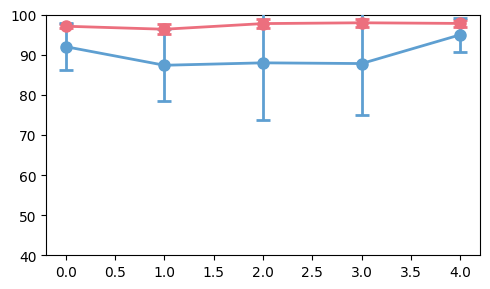

In [78]:
# 绘制calibration_model的评估指标折线图

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')

# 加载矩阵（如果还没有运行前面的cell）
if 'calibration_metrics_matrix' not in globals():
    calibration_metrics_matrix = np.load(base_dir / 'calibration_metrics_matrix.npy')

dates = [1215, 1216, 1217, 1218, 1219]
n_clique = 4
n_date = len(dates)

# 指标索引
# 0: noise_classifier_accuracy
# 1: accuracy_excluding_noise
noise_acc_idx = 0
label_acc_idx = 1

# 提取两个指标的数据
# calibration_metrics_matrix形状: (n_clique, n_metrics, n_date, n_rep)
noise_acc_data = calibration_metrics_matrix[:, noise_acc_idx, :, :]  # (n_clique, n_date, n_rep)
label_acc_data = calibration_metrics_matrix[:, label_acc_idx, :, :]  # (n_clique, n_date, n_rep)

# 整合所有clique的数据：将clique维度合并到rep维度
# 重新reshape: (n_clique, n_date, n_rep) -> (n_date, n_clique * n_rep)
noise_acc_combined = noise_acc_data.reshape(n_clique * n_date, -1).T  # (n_rep, n_clique * n_date)
label_acc_combined = label_acc_data.reshape(n_clique * n_date, -1).T  # (n_rep, n_clique * n_date)

# 对每个日期，计算所有clique和所有重复的均值和标准差
noise_means = []
noise_stds = []
label_means = []
label_stds = []

for date_idx in range(n_date):
    # 提取该日期所有clique所有重复的数据
    noise_date_data = noise_acc_data[:, date_idx, :].flatten()  # (n_clique * n_rep,)
    label_date_data = label_acc_data[:, date_idx, :].flatten()  # (n_clique * n_rep,)
    
    # 计算均值和标准差（排除NaN）
    noise_mean = np.nanmean(noise_date_data)
    noise_std = np.nanstd(noise_date_data)
    label_mean = np.nanmean(label_date_data)
    label_std = np.nanstd(label_date_data)
    
    noise_means.append(noise_mean)
    noise_stds.append(noise_std)
    label_means.append(label_mean)
    label_stds.append(label_std)

noise_means = np.array(noise_means)
noise_stds = np.array(noise_stds)
label_means = np.array(label_means)
label_stds = np.array(label_stds)

print(f"数据形状: {calibration_metrics_matrix.shape}")
print(f"整合后每个日期的数据点数量: {n_clique * n_rep} (4个clique × 5个重复)")
print(f"noise_classifier_accuracy均值范围: [{np.nanmin(noise_means):.4f}, {np.nanmax(noise_means):.4f}]")
print(f"accuracy_excluding_noise均值范围: [{np.nanmin(label_means):.4f}, {np.nanmax(label_means):.4f}]")

# 绘制折线图
fig, ax = plt.subplots(figsize=(5, 3))

# 颜色定义
noise_color = '#EC6F7E'
label_color = '#5E9FD1'

# x轴位置（日期）
x_positions = np.arange(n_date)
date_labels = [f'Date {date}' for date in dates]

# 绘制noise_classifier_accuracy
noise_mean_pct = noise_means * 100  # 转换为百分比
noise_std_pct = noise_stds * 100

ax.errorbar(x_positions, noise_mean_pct, yerr=noise_std_pct,
           marker='o', linestyle='-', linewidth=2, markersize=8,
           color=noise_color, label='Noise Classifier', 
           capsize=5, capthick=2, zorder=4)

# 绘制accuracy_excluding_noise
label_mean_pct = label_means * 100  # 转换为百分比
label_std_pct = label_stds * 100

ax.errorbar(x_positions, label_mean_pct, yerr=label_std_pct,
           marker='o', linestyle='-', linewidth=2, markersize=8,
           color=label_color, label='Label Classifier', 
           capsize=5, capthick=2, zorder=4)

# 设置图表属性
ax.set_ylim([40, 100])

plt.tight_layout()

# 保存图表
output_pdf_path = base_dir / 'calibration_accuracy_comparison.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
plt.show()


n_overlapping_neurons (求和值): [57. 62. 39. 36. 32.]
n_matched_neurons (均值): [44.2 47.  30.  31.2 31. ]
n_matched_neurons (标准差): [2.4        1.41421356 1.26491106 1.6        1.67332005]

✓ 已保存柱状图: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/neuron_counts_barplot.pdf


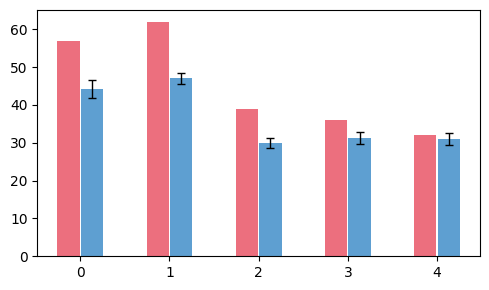

In [91]:
# 绘制n_overlapping_neurons和n_matched_neurons的柱状图

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')

# 加载矩阵（如果还没有运行前面的cell）
if 'calibration_metrics_matrix' not in globals():
    calibration_metrics_matrix = np.load(base_dir / 'calibration_metrics_matrix.npy')

dates = [1215, 1216, 1217, 1218, 1219]
n_clique = 4
n_date = len(dates)
n_rep = 5

# 指标索引
# 2: n_overlapping_neurons
# 3: n_matched_neurons
overlapping_idx = 2
matched_idx = 3

# 提取两个指标的数据
# calibration_metrics_matrix形状: (n_clique, n_metrics, n_date, n_rep)
overlapping_data = calibration_metrics_matrix[:, overlapping_idx, :, :]  # (n_clique, n_date, n_rep)
matched_data = calibration_metrics_matrix[:, matched_idx, :, :]  # (n_clique, n_date, n_rep)

# 对每个日期，计算4个clique的求和值
overlapping_sums = []  # 每个日期，所有clique的求和（只取一个重复，因为5个重复都一样）
matched_means = []     # 每个日期，所有clique的均值（跨重复）
matched_stds = []      # 每个日期，所有clique的标准差（跨重复）

for date_idx in range(n_date):
    # n_overlapping_neurons: 只取第一个重复（rep_idx=0），然后对4个clique求和
    overlapping_date_data = overlapping_data[:, date_idx, 0]  # (n_clique,)
    overlapping_sum = np.nansum(overlapping_date_data)  # 对4个clique求和
    overlapping_sums.append(overlapping_sum)
    
    # n_matched_neurons: 对每个重复，先对4个clique求和，然后计算跨重复的均值和标准差
    matched_date_data = matched_data[:, date_idx, :]  # (n_clique, n_rep)
    # 对每个重复，先对clique求和，得到(n_rep,)的数组
    matched_per_rep = np.nansum(matched_date_data, axis=0)  # (n_rep,)
    # 计算跨重复的均值和标准差
    matched_mean = np.nanmean(matched_per_rep)
    matched_std = np.nanstd(matched_per_rep)
    matched_means.append(matched_mean)
    matched_stds.append(matched_std)

overlapping_sums = np.array(overlapping_sums)
matched_means = np.array(matched_means)
matched_stds = np.array(matched_stds)

print(f"n_overlapping_neurons (求和值): {overlapping_sums}")
print(f"n_matched_neurons (均值): {matched_means}")
print(f"n_matched_neurons (标准差): {matched_stds}")

# 绘制柱状图
fig, ax = plt.subplots(figsize=(5, 3))

# 颜色定义
overlapping_color = '#EC6F7E'
matched_color = '#5E9FD1'

# x轴位置
x_positions = np.arange(n_date)
bar_width = 0.25  # 柱子宽度

# 绘制n_overlapping_neurons的柱子（无errorbar）
bars1 = ax.bar(x_positions - bar_width/2 *1.05, overlapping_sums, bar_width,
               color=overlapping_color, label='n_overlapping_neurons')

# 绘制n_matched_neurons的柱子（带errorbar）
bars2 = ax.bar(x_positions + bar_width/2 *1.05, matched_means, bar_width,
               color=matched_color, label='n_matched_neurons', yerr=matched_stds,
               capsize=3, error_kw={'linewidth': 1, 'capthick': 1})



plt.tight_layout()

# 保存图表
output_pdf_path = base_dir / 'neuron_counts_barplot.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
print(f"\n✓ 已保存柱状图: {output_pdf_path}")

plt.show()


In [ ]:
# 计算real_time_processing的耗时
import time
import torch
import importlib
import sys

# 重新加载模块以确保使用最新版本
if 'utils_clique' in sys.modules:
    importlib.reload(sys.modules['utils_clique'])

from utils_clique import real_time_processing, SimpleAutoSort, get_recording_clique, neuron_inf_dict_to_dataframe

# 使用neuropixels_test.ipynb的数据路径
mearec_data_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/data_generation/recording_neuropixels_150_Neuron_3600s.h5"
output_folder = '/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/data_generation/recording_neuropixels_150_Neuron_3600s'

# 加载recording数据
print("=" * 60)
print("加载MEArec数据...")
print("=" * 60)
recording, sorting = se.read_mearec(mearec_data_path)
probe = recording.get_probe()
recording_recorded = spre.bandpass_filter(recording, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")
probe.set_contact_ids(recording.channel_ids)

# 加载clique信息
clique_info_path = f'{output_folder}/clique_info.pkl'
with open(clique_info_path, 'rb') as f:
    clique_info = pickle.load(f)
cliques = clique_info['cliques']

# 设置测试参数
segment_idx = 0  # 使用segment_0
model_repeat = 1  # 使用model_1
test_segment_idx = 0  # 测试segment_0

# 获取所有clique IDs
all_clique_ids = list(range(len(cliques)))
print(f"将并行处理 {len(all_clique_ids)} 个clique: {all_clique_ids}")

# 定义处理单个clique的函数
def process_single_clique(clique_id):
    """处理单个clique的real_time_processing测试"""
    try:
        print(f"\n[Clique {clique_id}] 开始处理...")
        
        # 构建路径
        train_segment_folder = f'{output_folder}/clique_{clique_id}/segment_{segment_idx}'
        test_segment_folder = f'{output_folder}/clique_{clique_id}/segment_{test_segment_idx}'
        model_save_dir = f'{train_segment_folder}/model_{model_repeat}'
        
        # 检查文件是否存在
        train_neuron_inf_path = f'{train_segment_folder}/neuron_inf.pickle'
        calibration_results_path = f'{test_segment_folder}/calibration_model_{model_repeat}.pkl'
        keep_id_path = f'{model_save_dir}/keep_id.pkl'
        noise_model_path = f'{model_save_dir}/multitask_single_wave_clsfier_noise_clsfier.pth'
        label_model_path = f'{model_save_dir}/multitask_single_wave_clsfier_label_clsfier.pth'
        
        if not all([os.path.exists(p) for p in [train_neuron_inf_path, calibration_results_path, keep_id_path, noise_model_path, label_model_path]]):
            print(f"[Clique {clique_id}] 警告: 缺少必要文件，跳过")
            return None
        
        # 加载训练neuron_inf
        with open(train_neuron_inf_path, 'rb') as f:
            train_neuron_inf_dict = pickle.load(f)
        train_neuron_inf = neuron_inf_dict_to_dataframe(train_neuron_inf_dict)
        
        # 加载calibration_results
        with open(calibration_results_path, 'rb') as f:
            calibration_results = pickle.load(f)
        
        # 获取recording_clique
        clique = cliques[clique_id]
        recording_clique = get_recording_clique(recording_f, clique)
        
        # 加载模型
        n_channels = recording_clique.get_num_channels()
        samplepoints = 30
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # 加载keep_id
        with open(keep_id_path, 'rb') as f:
            keep_id_list = pickle.load(f)
        
        # 创建并加载模型
        autosort_model = SimpleAutoSort(
            ch_num=n_channels,
            samplepoints=samplepoints,
            device=device,
            set_shank_id=keep_id_list,
            save_dir=model_save_dir,
            pos_weight_noise=None,
            pos_weight_label=None
        )
        
        autosort_model.clsfier_noise.load_state_dict(torch.load(noise_model_path, map_location=device))
        autosort_model.clsfier_label.load_state_dict(torch.load(label_model_path, map_location=device))
        autosort_model.eval()
        
        print(f"[Clique {clique_id}] 模型加载完成 (Channels: {n_channels}, Device: {device})")
        
        # 存储该clique的所有结果
        clique_results = {}
        
        # 对每个time_window进行测试
        for tw_idx, time_window_seconds in enumerate(time_windows_seconds):
            time_window_ms = time_windows_ms[tw_idx]
            print(f"[Clique {clique_id}] 测试 Time Window: {time_window_ms} ms")
            
            # 计算需要处理的总时长
            total_duration_seconds = max(1.0, time_window_seconds * 10)
            
            elapsed_times = []
            
            # 重复100次
            for repeat_idx in range(n_repeats):
                if (repeat_idx + 1) % 20 == 0:
                    print(f"[Clique {clique_id}]  {time_window_ms}ms: 进度 {repeat_idx + 1}/{n_repeats}")
                
                # 测量单次耗时
                start_time = time.time()
                
                processing_results = real_time_processing(
                    recording_f=recording_clique,
                    autosort_model=autosort_model,
                    calibration_results=calibration_results,
                    start_time_seconds=start_time_seconds,
                    time_window_seconds=time_window_seconds,
                    total_duration_seconds=total_duration_seconds,
                    detection_params=detection_params,
                    window_params=window_params,
                    eval_neuron_inf=eval_neuron_inf,
                    eval_spike_inf=eval_spike_inf,
                    device=device,
                    batch_size=2048,  # 优化：增大批处理大小（从512增加到2048）
                    verbose=False,  # 优化：禁用详细输出以提升性能
                    save_noise_features=False,  # 优化：不保存noise visualization数据
                )
                
                end_time = time.time()
                elapsed_time = end_time - start_time
                elapsed_times.append(elapsed_time)
            
            # 计算统计信息
            mean_time = statistics.mean(elapsed_times)
            median_time = statistics.median(elapsed_times)
            min_time = min(elapsed_times)
            max_time = max(elapsed_times)
            std_time = statistics.stdev(elapsed_times) if len(elapsed_times) > 1 else 0.0
            
            # 计算实时因子
            n_windows = int(total_duration_seconds / time_window_seconds)
            realtime_factor = total_duration_seconds / mean_time
            
            # 存储结果
            clique_results[time_window_ms] = {
                'time_window_ms': time_window_ms,
                'time_window_seconds': time_window_seconds,
                'total_duration_seconds': total_duration_seconds,
                'n_windows': n_windows,
                'n_repeats': n_repeats,
                'elapsed_times': elapsed_times,
                'mean_time': mean_time,
                'median_time': median_time,
                'min_time': min_time,
                'max_time': max_time,
                'std_time': std_time,
                'realtime_factor': realtime_factor,
                'mean_time_per_window': mean_time / n_windows,
            }
            
            print(f"[Clique {clique_id}] {time_window_ms}ms: 平均耗时 {mean_time:.4f}s, 实时因子 {realtime_factor:.2f}x")
        
        print(f"[Clique {clique_id}] 处理完成!")
        return {'clique_id': clique_id, 'results': clique_results}
        
    except Exception as e:
        print(f"[Clique {clique_id}] 错误: {e}")
        import traceback
        traceback.print_exc()
        return None

# 设置real_time_processing参数
import statistics

start_time_seconds = 60.0  # 从60秒开始（calibration之后）
# 测试不同的time_window（毫秒转换为秒）
time_windows_ms = [50, 100, 200, 500, 1000]
time_windows_seconds = [tw / 1000.0 for tw in time_windows_ms]
n_repeats = 100  # 每个time_window重复100次

detection_params = {
    'thr_min': 2.5,
    'thr_max': 10,
    'distance': 6,
    'wlen': 5,
    'prominence': 10,
    'max_firing_channel': 8,
}

window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

# 不加载评估数据（只计算时间，不关心准确率）
eval_neuron_inf = None
eval_spike_inf = None

print(f"\n{'=' * 60}")
print(f"开始测试real_time_processing耗时（并行处理所有clique）")
print(f"{'=' * 60}")
print(f"测试参数:")
print(f"  - Cliques: {all_clique_ids}")
print(f"  - Start time: {start_time_seconds} seconds")
print(f"  - Time windows: {time_windows_ms} ms ({time_windows_seconds} seconds)")
print(f"  - Repeats per window: {n_repeats}")
print(f"  - Total tests per clique: {len(time_windows_ms) * n_repeats}")
print(f"  - Total tests (all cliques): {len(all_clique_ids) * len(time_windows_ms) * n_repeats}")
print(f"{'=' * 60}\n")

# 使用并行处理
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

# 存储所有clique的结果
all_clique_results = {}
lock = threading.Lock()

# 使用线程池并行处理所有clique
# 注意：如果使用GPU，可能需要限制并发数以避免GPU内存不足
max_workers = min(len(all_clique_ids), 32)  # 最多4个并发，避免GPU内存问题
print(f"使用 {max_workers} 个线程并行处理\n")

start_time_all = time.time()

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    # 提交所有任务
    future_to_clique = {executor.submit(process_single_clique, cid): cid for cid in all_clique_ids}
    
    # 收集结果
    for future in as_completed(future_to_clique):
        clique_id = future_to_clique[future]
        try:
            result = future.result()
            if result is not None:
                all_clique_results[clique_id] = result['results']
                print(f"\n[主线程] Clique {clique_id} 完成")
            else:
                print(f"\n[主线程] Clique {clique_id} 返回None（可能缺少文件）")
        except Exception as e:
            print(f"\n[主线程] Clique {clique_id} 发生异常: {e}")
            import traceback
            traceback.print_exc()

end_time_all = time.time()
total_elapsed_time = end_time_all - start_time_all

print(f"\n{'=' * 60}")
print(f"所有clique处理完成!")
print(f"总耗时: {total_elapsed_time:.2f} 秒 ({total_elapsed_time/60:.2f} 分钟)")
print(f"{'=' * 60}\n")

# 汇总所有clique的结果（按time_window聚合）
aggregated_results = {}

for tw_ms in time_windows_ms:
    # 收集所有clique的该time_window的结果
    all_elapsed_times = []
    clique_stats = {}
    
    for clique_id, clique_results in all_clique_results.items():
        if tw_ms in clique_results:
            result = clique_results[tw_ms]
            all_elapsed_times.extend(result['elapsed_times'])
            clique_stats[clique_id] = {
                'mean_time': result['mean_time'],
                'std_time': result['std_time'],
                'realtime_factor': result['realtime_factor'],
            }
    
    if len(all_elapsed_times) > 0:
        # 计算所有clique的聚合统计
        mean_time = statistics.mean(all_elapsed_times)
        median_time = statistics.median(all_elapsed_times)
        min_time = min(all_elapsed_times)
        max_time = max(all_elapsed_times)
        std_time = statistics.stdev(all_elapsed_times) if len(all_elapsed_times) > 1 else 0.0
        
        total_duration_seconds = max(1.0, (tw_ms / 1000.0) * 10)
        n_windows = int(total_duration_seconds / (tw_ms / 1000.0))
        realtime_factor = total_duration_seconds / mean_time
        
        aggregated_results[tw_ms] = {
            'time_window_ms': tw_ms,
            'time_window_seconds': tw_ms / 1000.0,
            'total_duration_seconds': total_duration_seconds,
            'n_windows': n_windows,
            'n_repeats': n_repeats * len(clique_stats),  # 所有clique的总重复数
            'n_cliques': len(clique_stats),
            'elapsed_times': all_elapsed_times,
            'mean_time': mean_time,
            'median_time': median_time,
            'min_time': min_time,
            'max_time': max_time,
            'std_time': std_time,
            'realtime_factor': realtime_factor,
            'mean_time_per_window': mean_time / n_windows,
            'clique_stats': clique_stats,  # 每个clique的统计
        }

# 输出汇总结果
print(f"{'=' * 60}")
print(f"汇总结果（所有clique聚合）")
print(f"{'=' * 60}")
print(f"{'Time Window (ms)':<20} {'Mean Time (s)':<15} {'Std (s)':<12} {'Realtime Factor':<15} {'Time/Window (s)':<15} {'Cliques':<10}")
print(f"{'-' * 100}")
for tw_ms in time_windows_ms:
    if tw_ms in aggregated_results:
        result = aggregated_results[tw_ms]
        print(f"{tw_ms:<20} {result['mean_time']:<15.4f} {result['std_time']:<12.4f} {result['realtime_factor']:<15.2f} {result['mean_time_per_window']:<15.4f} {result['n_cliques']:<10}")

# 输出每个clique的详细结果
print(f"\n{'=' * 60}")
print(f"各Clique详细结果")
print(f"{'=' * 60}")
for clique_id in sorted(all_clique_results.keys()):
    print(f"\nClique {clique_id}:")
    clique_results = all_clique_results[clique_id]
    print(f"{'Time Window (ms)':<20} {'Mean Time (s)':<15} {'Std (s)':<12} {'Realtime Factor':<15}")
    print(f"{'-' * 65}")
    for tw_ms in time_windows_ms:
        if tw_ms in clique_results:
            result = clique_results[tw_ms]
            print(f"{tw_ms:<20} {result['mean_time']:<15.4f} {result['std_time']:<12.4f} {result['realtime_factor']:<15.2f}")

# 保存结果
output_path = f"{output_folder}/realtime_processing_timing_results_all_cliques.pkl"
with open(output_path, 'wb') as f:
    pickle.dump({
        'all_clique_results': all_clique_results,  # 每个clique的详细结果
        'aggregated_results': aggregated_results,  # 聚合结果
        'parameters': {
            'start_time_seconds': start_time_seconds,
            'time_windows_ms': time_windows_ms,
            'time_windows_seconds': time_windows_seconds,
            'n_repeats': n_repeats,
            'detection_params': detection_params,
            'window_params': window_params,
            'all_clique_ids': all_clique_ids,
            'segment_idx': segment_idx,
            'model_repeat': model_repeat,
            'test_segment_idx': test_segment_idx,
            'total_elapsed_time_seconds': total_elapsed_time,
        }
    }, f)
print(f"\n✓ 所有结果已保存到: {output_path}")



加载MEArec数据...
将并行处理 12 个clique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

开始测试real_time_processing耗时（并行处理所有clique）
测试参数:
  - Cliques: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
  - Start time: 60.0 seconds
  - Time windows: [50, 100, 200, 500, 1000] ms ([0.05, 0.1, 0.2, 0.5, 1.0] seconds)
  - Repeats per window: 100
  - Total tests per clique: 500
  - Total tests (all cliques): 6000

使用 12 个线程并行处理


[Clique 0] 开始处理...

[Clique 1] 开始处理...

[Clique 2] 开始处理...

[Clique 3] 开始处理...

[Clique 4] 开始处理...

[Clique 5] 开始处理...

[Clique 6] 开始处理...

[Clique 7] 开始处理...

[Clique 8] 开始处理...

[Clique 9] 开始处理...

[Clique 10] 开始处理...

[Clique 11] 开始处理...
[Clique 5] 模型加载完成 (Channels: 49, Device: cuda)
[Clique 5] 测试 Time Window: 50 ms

Processing window 1 (60.0s - 60.0s)
[Clique 0] 模型加载完成 (Channels: 49, Device: cuda)
[Clique 0] 测试 Time Window: 50 ms

Processing window 1 (60.0s - 60.0s)
[Clique 1] 模型加载完成 (Channels: 49, Device: cuda)
[Clique 1] 测试 Time Window: 50 ms

Processing window 1 (60.0s - 60.0s)
[Clique 8] 

In [92]:
# 计算每个日期4个clique的neuron总数

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')

dates = [1214, 1215, 1216, 1217, 1218, 1219]
n_clique = 4

# 存储每个日期的neuron总数
date_neuron_counts = {}  # {date: total_neuron_count}

print(f"开始计算每个日期的neuron总数...\n")

for date in dates:
    total_neurons = 0
    
    for clique_id in range(n_clique):
        clique_dir = base_dir / f'clique_{clique_id}'
        date_dir = clique_dir / f'date_{date}'
        neuron_inf_path = date_dir / 'neuron_inf.pickle'
        
        if not neuron_inf_path.exists():
            print(f"警告: {neuron_inf_path} 不存在，跳过")
            continue
        
        try:
            # 读取neuron_inf.pickle
            with open(neuron_inf_path, 'rb') as f:
                neuron_inf = pickle.load(f)
            
            # 如果是dict，转换为DataFrame或直接统计
            if isinstance(neuron_inf, dict):
                neuron_count = len(neuron_inf)
            elif isinstance(neuron_inf, pd.DataFrame):
                neuron_count = len(neuron_inf)
            else:
                # 尝试转换为list或array
                neuron_count = len(neuron_inf) if hasattr(neuron_inf, '__len__') else 0
            
            total_neurons += neuron_count
            print(f"  Clique {clique_id}, Date {date}: {neuron_count} neurons")
            
        except Exception as e:
            print(f"错误: 无法读取 {neuron_inf_path}: {e}")
            continue
    
    date_neuron_counts[date] = total_neurons
    print(f"Date {date}: 总计 {total_neurons} neurons (4个clique)\n")

# 打印汇总结果
print("=" * 50)
print("汇总结果:")
print("=" * 50)
for date in dates:
    count = date_neuron_counts.get(date, 0)
    print(f"Date {date}: {count} neurons")

# 保存结果
output_dict_path = base_dir / 'date_neuron_counts.pickle'
with open(output_dict_path, 'wb') as f:
    pickle.dump(date_neuron_counts, f)
print(f"\n✓ 已保存结果: {output_dict_path}")


开始计算每个日期的neuron总数...

  Clique 0, Date 1214: 17 neurons
  Clique 1, Date 1214: 12 neurons
  Clique 2, Date 1214: 13 neurons
  Clique 3, Date 1214: 31 neurons
Date 1214: 总计 73 neurons (4个clique)

  Clique 0, Date 1215: 16 neurons
  Clique 1, Date 1215: 12 neurons
  Clique 2, Date 1215: 23 neurons
  Clique 3, Date 1215: 24 neurons
Date 1215: 总计 75 neurons (4个clique)

  Clique 0, Date 1216: 22 neurons
  Clique 1, Date 1216: 19 neurons
  Clique 2, Date 1216: 22 neurons
  Clique 3, Date 1216: 27 neurons
Date 1216: 总计 90 neurons (4个clique)

  Clique 0, Date 1217: 19 neurons
  Clique 1, Date 1217: 18 neurons
  Clique 2, Date 1217: 22 neurons
  Clique 3, Date 1217: 16 neurons
Date 1217: 总计 75 neurons (4个clique)

  Clique 0, Date 1218: 22 neurons
  Clique 1, Date 1218: 23 neurons
  Clique 2, Date 1218: 19 neurons
  Clique 3, Date 1218: 17 neurons
Date 1218: 总计 81 neurons (4个clique)

  Clique 0, Date 1219: 20 neurons
  Clique 1, Date 1219: 20 neurons
  Clique 2, Date 1219: 17 neurons
  Clique 3,

Neuron总数: [73, 75, 90, 75, 81, 74]

✓ 已保存柱状图: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/total_neuron_counts_barplot.pdf


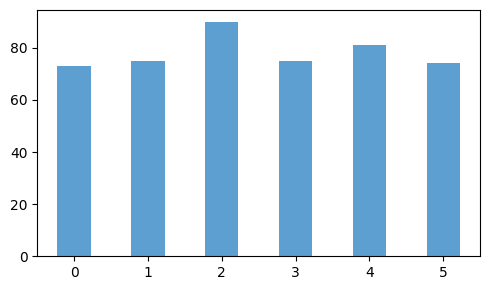

In [98]:
# 绘制每个日期neuron总数的柱状图

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2')

# 加载数据（如果还没有运行前面的cell）
if 'date_neuron_counts' not in globals():
    date_neuron_counts_path = base_dir / 'date_neuron_counts.pickle'
    if date_neuron_counts_path.exists():
        with open(date_neuron_counts_path, 'rb') as f:
            date_neuron_counts = pickle.load(f)
    else:
        print("错误: 请先运行前面的cell计算neuron总数")
        date_neuron_counts = {}

dates = [1214, 1215, 1216, 1217, 1218, 1219]

# 提取数据
neuron_counts = [date_neuron_counts.get(date, 0) for date in dates]

print(f"Neuron总数: {neuron_counts}")

# 绘制柱状图
fig, ax = plt.subplots(figsize=(5, 3))

# x轴位置
x_positions = np.arange(len(dates))
date_labels = [f'Date {date}' for date in dates]

# 绘制柱状图
bars = ax.bar(x_positions, neuron_counts, 0.45,
              color='#5E9FD1')

plt.tight_layout()

# 保存图表
output_pdf_path = base_dir / 'total_neuron_counts_barplot.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
print(f"\n✓ 已保存柱状图: {output_pdf_path}")

plt.show()


In [99]:
channel_list_A = ['A-000', 'A-001', 'A-002',
       'A-003', 'A-004', 'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
       'A-010', 'A-011', 'A-012', 'A-013', 'A-014', 'A-015', 'A-016',
       'A-017', 'A-018', 'A-019', 'A-020', 'A-021', 'A-022', 'A-023',
       'A-024', 'A-025', 'A-026', 'A-027', 'A-028', 'A-029', 'A-030',
       'A-031', 'A-032', 'A-033', 'A-034', 'A-035', 'A-036', 'A-037',
       'A-038', 'A-039', 'A-040', 'A-041', 'A-042', 'A-043', 'A-044',
       'A-045', 'A-046', 'A-047', 'A-048', 'A-049', 'A-050', 'A-051',
       'A-052', 'A-053', 'A-054', 'A-055', 'A-056', 'A-057', 'A-058',
       'A-059', 'A-060', 'A-061', 'A-062', 'A-063', 'A-064', 'A-065',
       'A-066', 'A-067', 'A-068', 'A-069', 'A-070', 'A-071', 'A-072',
       'A-073', 'A-074', 'A-075', 'A-076', 'A-077', 'A-078', 'A-079',
       'A-080', 'A-081', 'A-082', 'A-083', 'A-084', 'A-085', 'A-086',
       'A-087', 'A-088', 'A-089', 'A-090', 'A-091', 'A-092', 'A-093',
       'A-094', 'A-095', 'A-096', 'A-097', 'A-098', 'A-099', 'A-100',
       'A-101', 'A-102', 'A-103', 'A-104', 'A-105', 'A-106', 'A-107',
       'A-108', 'A-109', 'A-110', 'A-111', 'A-112', 'A-113', 'A-114',
       'A-115', 'A-116', 'A-117', 'A-118', 'A-119', 'A-120', 'A-121',
       'A-122', 'A-123', 'A-124', 'A-125', 'A-126', 'A-127']

channel_list_B = ['B-000', 'B-001', 'B-002',
       'B-003', 'B-004', 'B-005', 'B-006', 'B-007', 'B-008', 'B-009',
       'B-010', 'B-011', 'B-012', 'B-013', 'B-014', 'B-015', 'B-016',
       'B-017', 'B-018', 'B-019', 'B-020', 'B-021', 'B-022', 'B-023',
       'B-024', 'B-025', 'B-026', 'B-027', 'B-028', 'B-029', 'B-030',
       'B-031', 'B-032', 'B-033', 'B-034', 'B-035', 'B-036', 'B-037',
       'B-038', 'B-039', 'B-040', 'B-041', 'B-042', 'B-043', 'B-044',
       'B-045', 'B-046', 'B-047', 'B-048', 'B-049', 'B-050', 'B-051',
       'B-052', 'B-053', 'B-054', 'B-055', 'B-056', 'B-057', 'B-058',
       'B-059', 'B-060', 'B-061', 'B-062', 'B-063', 'B-064', 'B-065',
       'B-066', 'B-067', 'B-068', 'B-069', 'B-070', 'B-071', 'B-072',
       'B-073', 'B-074', 'B-075', 'B-076', 'B-077', 'B-078', 'B-079',
       'B-080', 'B-081', 'B-082', 'B-083', 'B-084', 'B-085', 'B-086',
       'B-087', 'B-088', 'B-089', 'B-090', 'B-091', 'B-092', 'B-093',
       'B-094', 'B-095', 'B-096', 'B-097', 'B-098', 'B-099', 'B-100',
       'B-101', 'B-102', 'B-103', 'B-104', 'B-105', 'B-106', 'B-107',
       'B-108', 'B-109', 'B-110', 'B-111', 'B-112', 'B-113', 'B-114',
       'B-115', 'B-116', 'B-117', 'B-118', 'B-119', 'B-120', 'B-121',
       'B-122', 'B-123', 'B-124', 'B-125', 'B-126', 'B-127']

data_path = '/media/ubuntu/sda/mouse_test/raw_data/WLF_128ch2mouse&V1B_natima_251214_154409'
file_list_path = Path(data_path)
rhd_files = list(file_list_path.glob("*.rhd"))
file_list = sorted(rhd_files)

# 读取并合并该date的所有rhd文件
recording_raw_list = []
for file in file_list:
    recording_raw_list.append(se.read_intan(file, stream_id='0'))

test_recording = concatenate_recordings(recording_list=recording_raw_list)

available_channels = test_recording.get_channel_ids()
if 'A-127' in available_channels:
    channel_list = channel_list_A
elif 'B-127' in available_channels:
    channel_list = channel_list_B


test_recording = test_recording.select_channels(channel_list)

# 统一将B开头的channel重命名为A开头
channel_ids = test_recording.get_channel_ids()
new_channel_ids = []
renamed_count = 0
for ch_id in channel_ids:
    if isinstance(ch_id, str) and ch_id.startswith('B-'):
        new_ch_id = 'A-' + ch_id[2:]
        new_channel_ids.append(new_ch_id)
        renamed_count += 1
    else:
        new_channel_ids.append(ch_id)

if renamed_count > 0:
    test_recording = test_recording.rename_channels(new_channel_ids)

test_recording = spre.unsigned_to_signed(test_recording)
test_recording = spre.resample(test_recording, 10000)
test_recording = spre.bandpass_filter(test_recording, freq_min=300, freq_max=3000)
test_recording = spre.notch_filter(test_recording, freq=50)
test_recording = spre.common_reference(test_recording, reference="global", operator="median")


In [106]:
traces_shank1 = test_recording.get_traces(start_frame = 1000, end_frame= 300 * 20000, channel_ids = ['A-008', 'A-009', 'A-010', 'A-011', 'A-014'])
traces_shank2 = test_recording.get_traces(start_frame = 1000, end_frame= 300 * 20000, channel_ids = ['A-000', 'A-001', 'A-002', 'A-003', 'A-004'])

In [114]:
n_time, n_channels = traces_shank1.shape
print(f"Traces数据形状: ({n_time}, {n_channels})")

sampling_rate = 10000
time_window_sec = 1.5
window_samples = int(time_window_sec * sampling_rate)
total_time_sec = n_time / sampling_rate  # 根据数据长度计算总时间
n_windows = int(np.ceil(total_time_sec / time_window_sec))

print(f"采样率: {sampling_rate} Hz")
print(f"总时间: {total_time_sec:.2f} 秒")
print(f"Time window: {time_window_sec}s ({window_samples} samples)")
print(f"总窗口数: {n_windows}")
print(f"总channel数: {n_channels}")

colors = plt.cm.tab20(np.linspace(0, 1, 20))

output_pdf_path = base_dir / 'raw_traces_1.5s_shank1.pdf'

with PdfPages(output_pdf_path) as pdf:
    for window_idx in range(20):
        start_sample = window_idx * window_samples
        end_sample = min(start_sample + window_samples, traces_shank1.shape[0])
        
        if start_sample >= traces_shank1.shape[0]:
            break
        
        fig, axes = plt.subplots(n_channels, 1, figsize=(8, n_channels * 0.6))
        
        fig.patch.set_alpha(0)
        fig.patch.set_facecolor('none')
        
        for channel_idx in range(n_channels):
            ax = axes[channel_idx]
            
            # 设置每个subplot的背景为透明
            ax.patch.set_alpha(0)
            ax.patch.set_facecolor('none')
            
            # 获取该channel的数据
            window_data = traces_shank1[start_sample:end_sample, channel_idx]
            
            # 转换为时间轴（秒）
            time_axis = np.arange(len(window_data)) / sampling_rate
            
            # 绘制，使用不同的颜色
            color_idx = channel_idx % len(colors)
            ax.plot(time_axis, window_data, color=colors[color_idx], linewidth=0.5)
            
            # 设置y轴范围（可以根据数据调整）
            y_min, y_max = window_data.min(), window_data.max()
            y_range = y_max - y_min
            if y_range > 0:
                ax.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)
            else:
                ax.set_ylim(-100, 100)
                
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
        
        if window_idx == n_windows - 1:
            axes[-1].spines['bottom'].set_visible(True)
            axes[-1].set_xlabel('Time (s)', fontsize=10)
            axes[-1].set_xticks([0, time_window_sec])
        
        plt.suptitle(f'Window {window_idx + 1}/{n_windows} ({window_idx * time_window_sec:.1f}s - {min((window_idx + 1) * time_window_sec, total_time_sec):.1f}s)', 
                     fontsize=10, y=0.995)
        plt.tight_layout(pad=0.1)
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0, transparent=True, facecolor='none')
        plt.close(fig)
        
        if (window_idx + 1) % 1 == 0:
            print(f"  已生成 {window_idx + 1}/{n_windows} 页")

print(f"✓ 保存: {output_pdf_path}")

n_time, n_channels = traces_shank2.shape
print(f"Traces数据形状: ({n_time}, {n_channels})")


output_pdf_path = base_dir / 'raw_traces_1.5s_shank2.pdf'

with PdfPages(output_pdf_path) as pdf:
    for window_idx in range(20):
        start_sample = window_idx * window_samples
        end_sample = min(start_sample + window_samples, traces_shank2.shape[0])
        
        if start_sample >= traces_shank2.shape[0]:
            break
        
        fig, axes = plt.subplots(n_channels, 1, figsize=(8, n_channels * 0.6))
        
        fig.patch.set_alpha(0)
        fig.patch.set_facecolor('none')
        
        for channel_idx in range(n_channels):
            ax = axes[channel_idx]
            
            # 设置每个subplot的背景为透明
            ax.patch.set_alpha(0)
            ax.patch.set_facecolor('none')
            
            # 获取该channel的数据
            window_data = traces_shank2[start_sample:end_sample, channel_idx]
            
            # 转换为时间轴（秒）
            time_axis = np.arange(len(window_data)) / sampling_rate
            
            # 绘制，使用不同的颜色
            color_idx = channel_idx % len(colors)
            ax.plot(time_axis, window_data, color=colors[color_idx + 5], linewidth=0.5)
            
            # 设置y轴范围（可以根据数据调整）
            y_min, y_max = window_data.min(), window_data.max()
            y_range = y_max - y_min
            if y_range > 0:
                ax.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)
            else:
                ax.set_ylim(-100, 100)
                
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
        
        if window_idx == n_windows - 1:
            axes[-1].spines['bottom'].set_visible(True)
            axes[-1].set_xlabel('Time (s)', fontsize=10)
            axes[-1].set_xticks([0, time_window_sec])
        
        plt.suptitle(f'Window {window_idx + 1}/{n_windows} ({window_idx * time_window_sec:.1f}s - {min((window_idx + 1) * time_window_sec, total_time_sec):.1f}s)', 
                     fontsize=10, y=0.995)
        plt.tight_layout(pad=0.1)
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0, transparent=True, facecolor='none')
        plt.close(fig)
        
        if (window_idx + 1) % 1 == 0:
            print(f"  已生成 {window_idx + 1}/{n_windows} 页")

print(f"✓ 保存: {output_pdf_path}")

Traces数据形状: (5999000, 5)
采样率: 10000 Hz
总时间: 599.90 秒
Time window: 1.5s (15000 samples)
总窗口数: 400
总channel数: 5
  已生成 1/400 页
  已生成 2/400 页
  已生成 3/400 页
  已生成 4/400 页
  已生成 5/400 页
  已生成 6/400 页
  已生成 7/400 页
  已生成 8/400 页
  已生成 9/400 页
  已生成 10/400 页
  已生成 11/400 页
  已生成 12/400 页
  已生成 13/400 页
  已生成 14/400 页
  已生成 15/400 页
  已生成 16/400 页
  已生成 17/400 页
  已生成 18/400 页
  已生成 19/400 页
  已生成 20/400 页
✓ 保存: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/raw_traces_1.5s_shank1.pdf
Traces数据形状: (5999000, 5)
  已生成 1/400 页
  已生成 2/400 页
  已生成 3/400 页
  已生成 4/400 页
  已生成 5/400 页
  已生成 6/400 页
  已生成 7/400 页
  已生成 8/400 页
  已生成 9/400 页
  已生成 10/400 页
  已生成 11/400 页
  已生成 12/400 页
  已生成 13/400 页
  已生成 14/400 页
  已生成 15/400 页
  已生成 16/400 页
  已生成 17/400 页
  已生成 18/400 页
  已生成 19/400 页
  已生成 20/400 页
✓ 保存: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/raw_traces_1.5s_shank2.pdf


In [117]:
n_time, n_channels = traces_shank1.shape
print(f"Traces数据形状: ({n_time}, {n_channels})")

sampling_rate = 10000
time_window_sec = 100 / 1000
window_samples = int(time_window_sec * sampling_rate)
total_time_sec = n_time / sampling_rate  # 根据数据长度计算总时间
n_windows = int(np.ceil(total_time_sec / time_window_sec))

print(f"采样率: {sampling_rate} Hz")
print(f"总时间: {total_time_sec:.2f} 秒")
print(f"Time window: {time_window_sec}s ({window_samples} samples)")
print(f"总窗口数: {n_windows}")
print(f"总channel数: {n_channels}")

colors = plt.cm.tab20(np.linspace(0, 1, 20))

output_pdf_path = base_dir / 'raw_traces_100ms_shank1.pdf'

with PdfPages(output_pdf_path) as pdf:
    for window_idx in range(20):
        start_sample = window_idx * window_samples
        end_sample = min(start_sample + window_samples, traces_shank1.shape[0])
        
        if start_sample >= traces_shank1.shape[0]:
            break
        
        fig, axes = plt.subplots(n_channels, 1, figsize=(12, n_channels * 0.6))
        
        fig.patch.set_alpha(0)
        fig.patch.set_facecolor('none')
        
        for channel_idx in range(n_channels):
            ax = axes[channel_idx]
            
            # 设置每个subplot的背景为透明
            ax.patch.set_alpha(0)
            ax.patch.set_facecolor('none')
            
            # 获取该channel的数据
            window_data = traces_shank1[start_sample:end_sample, channel_idx]
            
            # 转换为时间轴（秒）
            time_axis = np.arange(len(window_data)) / sampling_rate
            
            # 绘制，使用不同的颜色
            color_idx = channel_idx % len(colors)
            ax.plot(time_axis, window_data, color=colors[color_idx], linewidth=1.5)
            
            # 设置y轴范围（可以根据数据调整）
            y_min, y_max = window_data.min(), window_data.max()
            y_range = y_max - y_min
            if y_range > 0:
                ax.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)
            else:
                ax.set_ylim(-100, 100)
                
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
        
        if window_idx == n_windows - 1:
            axes[-1].spines['bottom'].set_visible(True)
            axes[-1].set_xlabel('Time (s)', fontsize=10)
            axes[-1].set_xticks([0, time_window_sec])
        
        plt.suptitle(f'Window {window_idx + 1}/{n_windows} ({window_idx * time_window_sec:.1f}s - {min((window_idx + 1) * time_window_sec, total_time_sec):.1f}s)', 
                     fontsize=10, y=0.995)
        plt.tight_layout(pad=0.1)
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0, transparent=True, facecolor='none')
        plt.close(fig)
        
        if (window_idx + 1) % 1 == 0:
            print(f"  已生成 {window_idx + 1}/{n_windows} 页")

print(f"✓ 保存: {output_pdf_path}")

n_time, n_channels = traces_shank2.shape
print(f"Traces数据形状: ({n_time}, {n_channels})")


output_pdf_path = base_dir / 'raw_traces_100ms_shank2.pdf'

with PdfPages(output_pdf_path) as pdf:
    for window_idx in range(20):
        start_sample = window_idx * window_samples
        end_sample = min(start_sample + window_samples, traces_shank2.shape[0])
        
        if start_sample >= traces_shank2.shape[0]:
            break
        
        fig, axes = plt.subplots(n_channels, 1, figsize=(12, n_channels * 0.6))
        
        fig.patch.set_alpha(0)
        fig.patch.set_facecolor('none')
        
        for channel_idx in range(n_channels):
            ax = axes[channel_idx]
            
            # 设置每个subplot的背景为透明
            ax.patch.set_alpha(0)
            ax.patch.set_facecolor('none')
            
            # 获取该channel的数据
            window_data = traces_shank2[start_sample:end_sample, channel_idx]
            
            # 转换为时间轴（秒）
            time_axis = np.arange(len(window_data)) / sampling_rate
            
            # 绘制，使用不同的颜色
            color_idx = channel_idx % len(colors)
            ax.plot(time_axis, window_data, color=colors[color_idx + 5], linewidth=1.5)
            
            # 设置y轴范围（可以根据数据调整）
            y_min, y_max = window_data.min(), window_data.max()
            y_range = y_max - y_min
            if y_range > 0:
                ax.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)
            else:
                ax.set_ylim(-100, 100)
                
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
        
        if window_idx == n_windows - 1:
            axes[-1].spines['bottom'].set_visible(True)
            axes[-1].set_xlabel('Time (s)', fontsize=10)
            axes[-1].set_xticks([0, time_window_sec])
        
        plt.suptitle(f'Window {window_idx + 1}/{n_windows} ({window_idx * time_window_sec:.1f}s - {min((window_idx + 1) * time_window_sec, total_time_sec):.1f}s)', 
                     fontsize=10, y=0.995)
        plt.tight_layout(pad=0.1)
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0, transparent=True, facecolor='none')
        plt.close(fig)
        
        if (window_idx + 1) % 1 == 0:
            print(f"  已生成 {window_idx + 1}/{n_windows} 页")

print(f"✓ 保存: {output_pdf_path}")

Traces数据形状: (5999000, 5)
采样率: 10000 Hz
总时间: 599.90 秒
Time window: 0.1s (1000 samples)
总窗口数: 5999
总channel数: 5
  已生成 1/5999 页
  已生成 2/5999 页
  已生成 3/5999 页
  已生成 4/5999 页
  已生成 5/5999 页
  已生成 6/5999 页
  已生成 7/5999 页
  已生成 8/5999 页
  已生成 9/5999 页
  已生成 10/5999 页
  已生成 11/5999 页
  已生成 12/5999 页
  已生成 13/5999 页
  已生成 14/5999 页
  已生成 15/5999 页
  已生成 16/5999 页
  已生成 17/5999 页
  已生成 18/5999 页
  已生成 19/5999 页
  已生成 20/5999 页
✓ 保存: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/raw_traces_100ms_shank1.pdf
Traces数据形状: (5999000, 5)
  已生成 1/5999 页
  已生成 2/5999 页
  已生成 3/5999 页
  已生成 4/5999 页
  已生成 5/5999 页
  已生成 6/5999 页
  已生成 7/5999 页
  已生成 8/5999 页
  已生成 9/5999 页
  已生成 10/5999 页
  已生成 11/5999 页
  已生成 12/5999 页
  已生成 13/5999 页
  已生成 14/5999 页
  已生成 15/5999 页
  已生成 16/5999 页
  已生成 17/5999 页
  已生成 18/5999 页
  已生成 19/5999 页
  已生成 20/5999 页
✓ 保存: /media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/raw_traces_100ms_shank2.pdf


✓ 加载 Neuropixel (384 channels): mean_time范围 [118.3175, 806.4053] 毫秒
✓ 加载 30 Channels (Mouse6): mean_time范围 [2.9281, 31.4751] 毫秒
✓ 加载 128 Channels (Mouse2): mean_time范围 [32.1366, 147.0079] 毫秒

✓ 图表已保存到: /media/ubuntu/sda/mouse_test/sorted/realtime_processing_timing_comparison.pdf


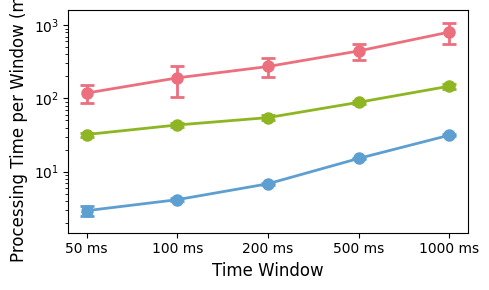

In [14]:
# 绘制real_time_processing运行时间对比图

import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 三个结果文件路径
result_files = [
    {
        'path': '/media/ubuntu/sda/Spike_Sorting/paper_architecture/02_simulation_data/02_Neuropixel_384_channels/data_generation/recording_neuropixels_150_Neuron_3600s/realtime_processing_timing_results_all_cliques.pkl',
        'label': 'Neuropixel (384 channels)',
        'color': '#EC6F7E'
    },
    {
        'path': '/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim/clique_0/mouse6_022522_natural_image_001/realtime_processing_timing_results.pkl',
        'label': '30 Channels (Mouse6)',
        'color': '#5E9FD1'
    },
    {
        'path': '/media/ubuntu/sda/mouse_test/sorted/combined_mountain_sort/mouse2/realtime_processing_timing_results_all_cliques.pkl',
        'label': '128 Channels (Mouse2)',
        'color': '#8eb623'
    }
]

# time_windows（统一为[50, 100, 200, 500, 1000]）
time_windows = [50, 100, 200, 500, 1000]

# 读取数据
all_data = []
for file_info in result_files:
    file_path = file_info['path']
    label = file_info['label']
    color = file_info['color']
    
    try:
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
        
        # 根据文件结构提取数据
        if 'aggregated_results' in data:
            results = data['aggregated_results']
        elif 'all_results' in data:
            results = data['all_results']
        else:
            print(f"警告: {label} 文件格式不匹配，跳过")
            continue
        
        # 提取每个time_window的mean_time和std_time
        # mean_time是处理10个窗口的总时间，需要除以10得到每个窗口的平均时间
        mean_times = []
        std_times = []
        
        for tw in time_windows:
            if tw in results:
                result = results[tw]
                # 优先使用mean_time_per_window，否则计算mean_time / n_windows
                if 'mean_time_per_window' in result:
                    mean_time_per_window = result['mean_time_per_window']
                else:
                    n_windows = result.get('n_windows', 10)  # 默认10个窗口
                    mean_time_per_window = result['mean_time'] / n_windows
                
                # std_time也需要除以n_windows（标准差除以窗口数）
                n_windows = result.get('n_windows', 10)
                std_time_per_window = result['std_time'] / n_windows
                
                # 转换为毫秒
                mean_times.append(mean_time_per_window * 1000)  # 秒转毫秒
                std_times.append(std_time_per_window * 1000)  # 秒转毫秒
            else:
                print(f"警告: {label} 缺少 {tw}ms 的数据")
                mean_times.append(np.nan)
                std_times.append(np.nan)
        
        all_data.append({
            'label': label,
            'color': color,
            'mean_times': np.array(mean_times),
            'std_times': np.array(std_times)
        })
        
        print(f"✓ 加载 {label}: mean_time范围 [{np.nanmin(mean_times):.4f}, {np.nanmax(mean_times):.4f}] 毫秒")
        
    except Exception as e:
        print(f"错误: 无法加载 {label}: {e}")

# 绘制折线图
fig, ax = plt.subplots(figsize=(5, 3))

# x轴位置
x_positions = np.arange(len(time_windows))
x_labels = [f'{tw} ms' for tw in time_windows]

# 绘制每条线
for data_info in all_data:
    label = data_info['label']
    color = data_info['color']
    mean_times = data_info['mean_times']
    std_times = data_info['std_times']
    
    # 只绘制非NaN的点
    valid_mask = ~np.isnan(mean_times)
    if np.any(valid_mask):
        ax.errorbar(x_positions[valid_mask], mean_times[valid_mask], yerr=std_times[valid_mask],
                   marker='o', linestyle='-', linewidth=2, markersize=8,
                   color=color, label=label,
                   capsize=5, capthick=2, zorder=4)

# 设置图表属性
ax.set_xlabel('Time Window', fontsize=12)
ax.set_ylabel('Processing Time per Window (ms)', fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
ax.set_yscale('log')  # 使用对数刻度

# 设置y轴范围（根据数据自动调整，但确保显示所有数据）
all_mean_times = np.concatenate([d['mean_times'] for d in all_data])
valid_times = all_mean_times[~np.isnan(all_mean_times)]
if len(valid_times) > 0:
    y_min = np.min(valid_times) * 0.5  # 对数刻度，从最小值的一半开始
    y_max = np.max(valid_times) * 2  # 最大值的两倍
    ax.set_ylim([y_min, y_max])

plt.tight_layout()

# 保存图表
output_pdf_path = Path('/media/ubuntu/sda/mouse_test/sorted') / 'realtime_processing_timing_comparison.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
print(f"\n✓ 图表已保存到: {output_pdf_path}")

plt.show()

